In [32]:
from qldpc_sim import *
from qldpc_sim.qldpc_experiment import *
from qldpc_sim.qec_code import *
from qldpc_sim.data_structure import *
from qldpc_sim.ckbb_surgery import *
import stim
import numpy as np

## Step 0: Context setup

define which codes are used for each logical qubits and set initial memory size.

In [ ]:
# block_1 = RotatedSurfaceCode.from_distance(3, code_name="code 1", system_coordinate=(0, 0))
# block_2 = RotatedSurfaceCode.from_distance(3, code_name="code 2", system_coordinate=(0, 1))
# block_3 = RotatedSurfaceCode.from_distance(3, code_name="code 3", system_coordinate=(0, 2))

# qm = qldpc_experiment.QuantumMemory(size=600)

# blocks = [block_1, block_2, block_3]
# mapqb = {}
# for c in blocks:
#     for lq in c.logical_qubits:
#         mapqb[lq.logical_x] = c
#         mapqb[lq.logical_z] = c

# context = Context(
#     codes=blocks, logical_qubits=block_1.logical_qubits + block_2.logical_qubits + block_3.logical_qubits, initial_assignement=mapqb, memory=qm
# )


In [39]:
block_1 = ToricCode.from_distance(3, code_name="code 1", system_coordinate=(0, 0))
block_2 = RotatedSurfaceCode.from_distance(3, code_name="code 2", system_coordinate=(0, 1))

qm = qldpc_experiment.QuantumMemory(size=600)

blocks = [block_1, block_2]
mapqb = {}
for c in blocks:
    for lq in c.logical_qubits:
        mapqb[lq.logical_x] = c
        mapqb[lq.logical_z] = c

context = Context(
    codes=blocks, logical_qubits=block_1.logical_qubits + block_2.logical_qubits, initial_assignement=mapqb, memory=qm
)

In [40]:
# control = block_1.logical_qubits[0]
# ancilla = block_2.logical_qubits[0]
# target = block_3.logical_qubits[0]

control = block_1.logical_qubits[0]
target = block_1.logical_qubits[1]
ancilla = block_2.logical_qubits[0]


## Step 2: CNOT in PBC language :

In [41]:


cnot_program = (
    [
        InitializeCode(
            code=b,
            context=context,
            tag=f"init_{b.id}",
            initial_state=PauliEigenState.Z_plus,
        ) for b in [block_1]
        # ) for b in [block_1, block_3]
    ] + [
        InitializeCode(
            code=block_2,
            context=context,
            tag=f"init_{block_2.id}",
            initial_state=PauliEigenState.X_plus,
        )
    ]
    + [
        StabMeasurement(code=b, context=context, tag=f"stab_measurement_1_{b.id}", round=3)
        for b in blocks
    ]
    + [
        CKBBMeasurement(
            distance=3,
            context=context,
            tag="Merge_C-A",
            logical_targets=[
                ancilla.logical_z,
                control.logical_z,
            ],
        ),
    ]
    + [
        StabMeasurement(code=b, context=context, tag=f"stab_measurement_2_{b.id}", round=3)
        for b in blocks
    ]
    + [
        CKBBMeasurement(
            distance=3,
            context=context,
            tag="Merge_T-A",
            logical_targets=[
                ancilla.logical_x,
                target.logical_x,
            ],
        ),
    ]
    + [
        StabMeasurement(code=b, context=context, tag=f"stab_measurement_3_{b.id}", round=3)
        for b in blocks
    ]
    + [
        LM(
            logical_targets=[ancilla.logical_z],
            context=context,
            tag=f"final_ancilla",
            basis=PauliChar.Z,
        ),
        LM(
            logical_targets=[target.logical_z],
            context=context,
            tag=f"final_target",
            basis=PauliChar.Z,
        ),
        LM(
            logical_targets=[control.logical_z],
            context=context,
            tag=f"final_control",
            basis=PauliChar.Z,
        ),
    ]
)

In [42]:
def evaluate(ctx, program):
    logical_outcomes = {}
    instructions = []

    for gadget in program:
        compilers, outcomes = gadget.build_compiler_instructions()

        for compiler in compilers:
            stim_lines, measurements = compiler.compile(ctx.memory)
            instructions.extend(stim_lines)
            if measurements is not None:
                ctx.record.add_measurements(measurements)

        for outcome in outcomes:
            ctx.record.add_event(outcome)

            if outcome.type == EventType.FRAME_CORRECTION:
                logical_qubit = ctx.map_operator_to_qubits[outcome.target]
                correction_type = outcome.target.logical_type
                ctx.frame_tracker.add_correction(
                    logical_qubit,
                    correction_type,
                    ctx.record.get_event_idx(outcome),
                )

            if outcome.type == EventType.OBSERVABLE:
                direct_nodes = set(outcome.measured_nodes)
                target_ops = (
                    [outcome.target]
                    if isinstance(outcome.target, LogicalOperator)
                    else [op for op in (outcome.target or set()) if isinstance(op, LogicalOperator)]
                )

                merged_corrections = set()
                for op in target_ops:
                    logical_qubit = ctx.map_operator_to_qubits[op]
                    merged_corrections ^= ctx.frame_tracker.get_correction(
                        logical_qubit,
                        op.logical_type,
                    )

                logical_outcomes[outcome.tag] = (outcome, merged_corrections)

    return instructions, logical_outcomes, ctx.record

Outcome index for Merge_C-A_parity_outcome: {224, 256, 230, 233, 234, 235, 267, 237, 270, 240, 242, 216, 249, 251, 252, 221, 222, 255}
Outcome for Merge_C-A_parity_outcome: [0 0 1 0 1]...
Outcome index for Merge_T-A_parity_outcome: {512, 515, 516, 519, 520, 524, 526, 273, 532, 536, 537, 538, 543, 544, 492, 493, 497, 501, 504}
Outcome for Merge_T-A_parity_outcome: [0 0 0 1 1]...
Outcome index for LogicalMeasurement_final_ancilla: {656, 561, 657, 658}
Outcome for LogicalMeasurement_final_ancilla: [0 0 1 1 1]...
Outcome index for LogicalMeasurement_final_target: {560, 659, 660, 661}
Outcome for LogicalMeasurement_final_target: [0 0 0 1 0]...
Outcome index for LogicalMeasurement_final_control: {664, 662, 663}
Outcome for LogicalMeasurement_final_control: [0 0 0 0 0]...


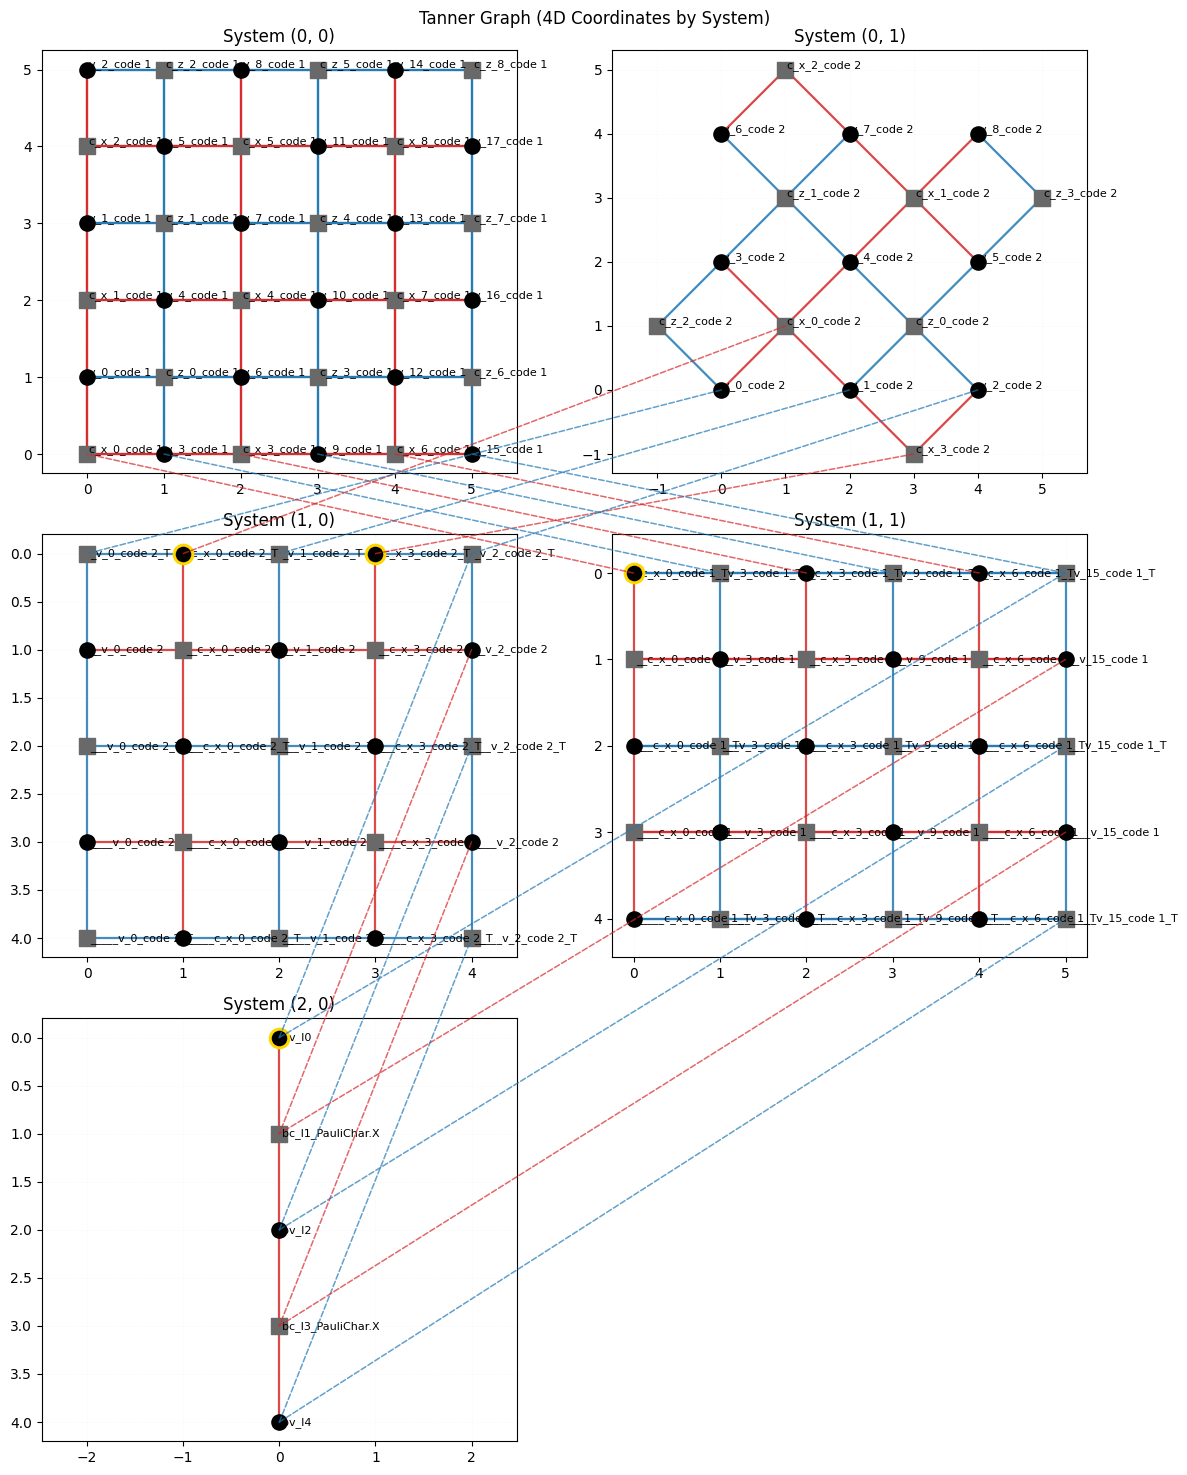

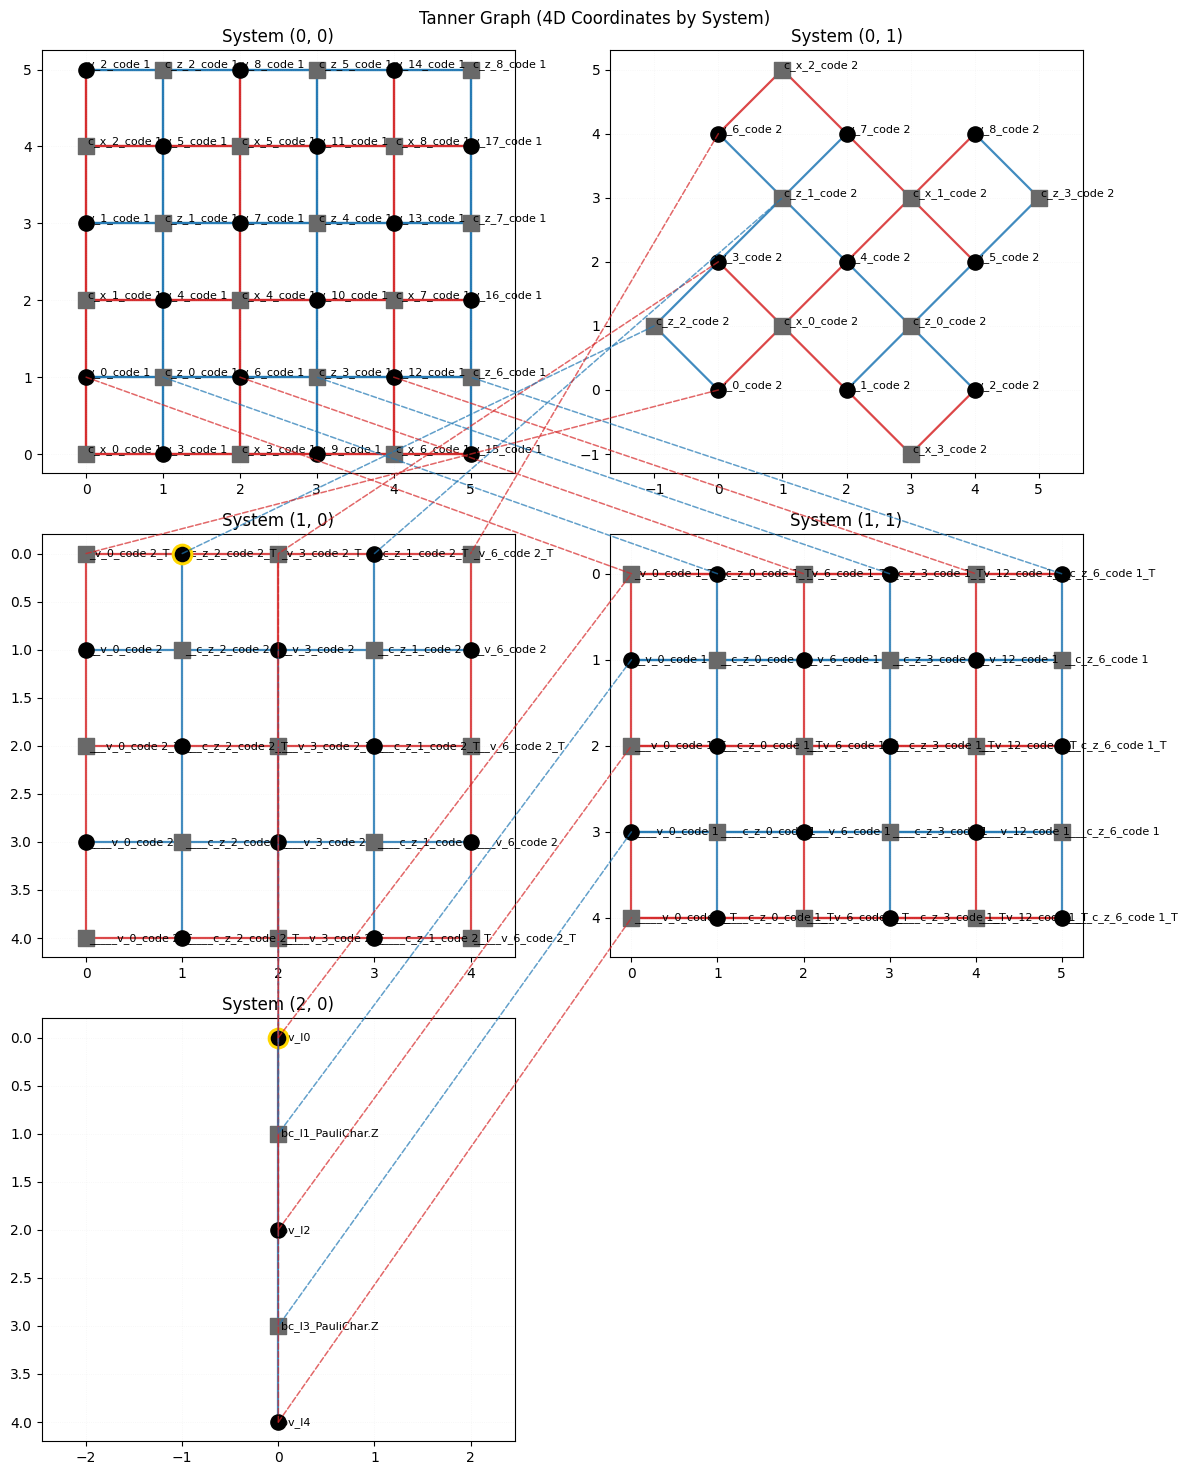

In [43]:
instructions, logical_outcomes, rec = evaluate(context, cnot_program)

num_shots = 100
shots = (
    stim.Circuit("\n".join(instructions))
    .compile_sampler()
    .sample(shots=num_shots)
    .astype(np.uint8)
)

outcomes_values = {}
for tag, outcomes in logical_outcomes.items():
    index = context.record.get_event_idx(outcomes[0]) ^ outcomes[1]
    print(f"Outcome index for {tag}: {index}")

    outcomes_values[tag] = np.bitwise_xor.reduce(shots[:, list(index)], axis=1)
    print(f"Outcome for {tag}: {outcomes_values[tag][:5]}...")

In [44]:
from collections import Counter

control_key = "LogicalMeasurement_final_control"
target_key = "LogicalMeasurement_final_target"
ancilla_key = "LogicalMeasurement_final_ancilla"
merge_ca_key = "Merge_C-A_parity_outcome"

final_control = outcomes_values[control_key]
final_target = outcomes_values[target_key] ^ outcomes_values[ancilla_key] ^ outcomes_values[merge_ca_key]

pair_counts = Counter(zip(final_control.tolist(), final_target.tolist()))
print("Outcome pair counts (control, target):")
print(dict(sorted(pair_counts.items())))

Outcome pair counts (control, target):
{(0, 0): 100}
